# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Maesa Sukma Ayu]
- **Email:** [cdcc180d6x2251@student.devacademy.id]
- **ID Dicoding:** [CDCC180D6X2251]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana tren penyewaan sepeda per jam dan harian pada periode tahun 2011-2012, dan faktor cuaca (suhu, kelembaban, windspeed) mana yang paling memengaruhi jumlah penyewaan?
- Pertanyaan 2: Bagaimana pola penyewaan sepeda per jam sepanjang hari pada tahun 2012, dan kapan puncak penggunaan terjadi bagi pengguna casual dan registered?

## Import Semua Packages/Library yang Digunakan

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

## Data Wrangling

### Gathering Data

In [41]:
# Load dataset
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 data teratas
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Struktur dataset harian (day_df) menunjukkan kolom-kolom yang lengkap untuk analisis tren penyewaan sepeda, termasuk tanggal (dteday), musim (season), faktor cuaca (temp, hum, windspeed), dan jumlah penyewaan (casual, registered, cnt). Dari data awal terlihat bahwa pengguna registered secara konsisten lebih banyak daripada casual, menandakan basis pelanggan tetap yang kuat sejak awal operasional. Selain itu, suhu memiliki pengaruh positif terhadap jumlah penyewaan, sedangkan kelembaban sedikit menekan penyewaan dan kecepatan angin relatif tidak terlalu berpengaruh. Hal ini mengindikasikan bahwa faktor cuaca, terutama suhu, merupakan determinan utama dalam perilaku penyewaan sepeda harian.
- Struktur dataset harian (day_df) menunjukkan kolom-kolom yang lengkap untuk analisis tren penyewaan sepeda, termasuk tanggal (dteday), musim (season), faktor cuaca (temp, hum, windspeed), dan jumlah penyewaan (casual, registered, cnt). Dari data awal terlihat bahwa pengguna registered secara konsisten lebih banyak daripada casual, menandakan basis pelanggan tetap yang kuat sejak awal operasional. Selain itu, suhu memiliki pengaruh positif terhadap jumlah penyewaan, sedangkan kelembaban sedikit menekan penyewaan dan kecepatan angin relatif tidak terlalu berpengaruh. Hal ini mengindikasikan bahwa faktor cuaca, terutama suhu, merupakan determinan utama dalam perilaku penyewaan sepeda harian.

### Assessing Data

In [42]:
hour_df.info()
hour_df.describe()
hour_df.duplicated().sum()
hour_df.isna().sum()
day_df.info()
day_df.describe()
day_df.duplicated().sum()
day_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Insight:**
- Pemeriksaan Struktur Data (.info()): Dataset day_df dan hour_df memiliki tipe data yang sesuai, namun kolom dteday masih bertipe object dan perlu dikonversi menjadi datetime untuk analisis berbasis waktu.
- Pengecekan Kelengkapan Data (.isna().sum()): Tidak ada nilai yang hilang pada seluruh kolom di kedua dataset, sehingga data dapat langsung digunakan tanpa perlu imputasi.
- Verifikasi Duplikasi Data (.duplicated().sum()): Tidak ditemukan entri data ganda, menandakan dataset bersih dari bias akibat duplikasi.
- Analisis Statistik Deskriptif (.describe()): Dataset sudah siap digunakan untuk menganalisis tren penyewaan sepeda harian dan per jam, serta hubungan dengan faktor cuaca seperti suhu, kelembaban, dan kecepatan angin.

### Cleaning Data

In [43]:
# Mapping untuk season
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].replace(season_labels)
hour_df['season'] = hour_df['season'].replace(season_labels)

# Mapping untuk weathersit
weather_labels = {
    1: 'Clear',
    2: 'Misty',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
}
day_df['weathersit'] = day_df['weathersit'].replace(weather_labels)
hour_df['weathersit'] = hour_df['weathersit'].replace(weather_labels)

# Mapping untuk weekday
weekday_labels = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
day_df['weekday'] = day_df['weekday'].replace(weekday_labels)
hour_df['weekday'] = hour_df['weekday'].replace(weekday_labels)

# 2. Mengubah yr (tahun) agar lebih jelas (0: 2011, 1: 2012)
year_labels = {0: '2011', 1: '2012'}
day_df['yr'] = day_df['yr'].replace(year_labels)
hour_df['yr'] = hour_df['yr'].replace(year_labels)

# Tampilkan hasil
day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,0,Sat,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,1,1,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,1,2,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,1,3,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,1,4,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kategorisasi Season, Weather, dan Weekday: Kolom season, weathersit, dan weekday telah berhasil diubah dari numerik menjadi label teks yang mudah dibaca. Hal ini meningkatkan keterbacaan data saat analisis dan visualisasi, serta memudahkan interpretasi bagi pengguna dashboard Streamlit.
- Klarifikasi Tahun (yr): Kolom yr telah diubah dari 0/1 menjadi 2011/2012, sehingga lebih jelas dan langsung dapat dipahami konteks waktunya saat melakukan analisis tren tahunan.
- Kesiapan Visualisasi: Dengan semua kategori diubah menjadi label teks, langkah ini memudahkan pembuatan visualisasi seperti bar chart atau line chart berdasarkan musim, hari dalam minggu, atau kondisi cuaca, sehingga grafik yang dihasilkan lebih intuitif.
- Konsistensi Data: Transformasi ini menjaga konsistensi antara dataset harian (day_df) dan per jam (hour_df), sehingga analisis lintas dataset bisa dilakukan tanpa perlu konversi ulang.

## Exploratory Data Analysis (EDA)



### Explore Pertanyaan 1 (melihat Perbandingan data harian dan data per jam) dan pertanyaan 2


In [44]:
# Explorasi Pertanyaan 1 (Perbandingan data harian dan data per jam)
# Agrasi Harian
daily_trend = day_df.groupby(["yr", "dteday"]).agg({
    "casual": "sum",
    "registered": "sum",
    "cnt": "sum",
    "temp": "mean",
    "hum": "mean",
    "windspeed": "mean"
}).reset_index()

# Agregasi Per Jam
hourly_trend = hour_df.groupby(["yr", "dteday", "hr"]).agg({
    "casual": "sum",
    "registered": "sum",
    "cnt": "sum",
    "temp": "mean",
    "hum": "mean",
    "windspeed": "mean"
}).reset_index()

# # Menampilkan data harian dan per jam untuk melihat perbandingan
daily_trend.head(25)  # Menampilkan data harian
hourly_trend.head(25)  # Menampilkan data per jam

,yr,dteday,hr,casual,registered,cnt,temp,hum,windspeed
0,2011,2011-01-01,0,3,13,16,0.24,0.81,0.0000
1,2011,2011-01-01,1,8,32,40,0.22,0.80,0.0000
2,2011,2011-01-01,2,5,27,32,0.22,0.80,0.0000
3,2011,2011-01-01,3,3,10,13,0.24,0.75,0.0000
4,2011,2011-01-01,4,0,1,1,0.24,0.75,0.0000
5,2011,2011-01-01,5,0,1,1,0.24,0.75,0.0896
6,2011,2011-01-01,6,2,0,2,0.22,0.80,0.0000
7,2011,2011-01-01,7,1,2,3,0.20,0.86,0.0000
8,2011,2011-01-01,8,1,7,8,0.24,0.75,0.0000
9,2011,2011-01-01,9,8,6,14,0.32,0.76,0.0000


In [45]:
# Explorasi Pertanyaan 2
# Filter data untuk tahun 2012
hour_2012 = hour_df[hour_df['yr'] == '2012']

# Agregasi penyewaan per jam sepanjang hari
hourly_pattern_2012 = hour_2012.groupby('hr').agg({
    'casual': 'mean',
    'registered': 'mean',
    'cnt': 'mean'
}).reset_index()

# Menampilkan hasil agregasi
hourly_pattern_2012

,hr,casual,registered,cnt
0,0,10.827397,53.802740,64.630137
1,1,7.247253,32.879121,40.126374
2,2,5.074380,21.622590,26.696970
3,3,2.645070,10.687324,13.332394
4,4,1.230556,6.022222,7.252778
5,5,1.604396,23.406593,25.010989
6,6,4.505495,89.810440,94.315934
7,7,11.728022,255.417582,267.145604
8,8,24.153846,430.609890,454.763736
9,9,37.346154,237.247253,274.593407


**Insight:**

Dari EDA diatas, maka dapat diperoleh hasil explorasi dari kedua pertanyaan bisnis, yaitu:
- Pertanyaan 1: Berdasarkan agregasi penyewaan sepeda per jam dan harian selama periode 2011–2012, terlihat tren bahwa jumlah penyewaan sepeda cenderung meningkat seiring waktu, dengan pengguna registered selalu lebih dominan dibandingkan pengguna casual. Penyewaan per jam menunjukkan pola puncak pada jam-jam pagi (sekitar 8–10) dan sore (sekitar 15–17), kemungkinan besar terkait jam kerja atau aktivitas rutin harian. Dari sisi faktor cuaca, jumlah penyewaan terlihat berkorelasi positif dengan suhu (temp dan atemp), sementara kelembaban (hum) dan kecepatan angin (windspeed) memiliki dampak negatif ringan terhadap jumlah penyewaan, artinya cuaca yang lebih sejuk dan tenang cenderung mendorong lebih banyak orang untuk menyewa sepeda. Secara keseluruhan, data ini menunjukkan bahwa tren penyewaan dipengaruhi kombinasi antara pola waktu harian dan kondisi cuaca.
- Pertanyaan 2: Analisis per jam untuk tahun 2012 menunjukkan pola penggunaan sepeda yang berbeda antara pengguna casual dan registered. Pengguna registered memiliki jumlah penyewaan yang konsisten lebih tinggi dan menunjukkan dua puncak utama, yaitu pagi sekitar jam 7–9 dan sore sekitar jam 17–18, menandakan penggunaan terkait kegiatan rutin seperti pergi dan pulang kerja. Sementara itu, pengguna casual memiliki jumlah penyewaan lebih rendah dan cenderung meningkat pada jam siang hingga sore hari, menandakan penggunaan yang lebih bersifat rekreasional atau sporadis. Puncak total penyewaan terjadi pada jam 17, ketika gabungan casual dan registered mencapai angka tertinggi, menunjukkan jam sibuk operasional sepeda yang harus diperhatikan untuk manajemen stok dan ketersediaan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

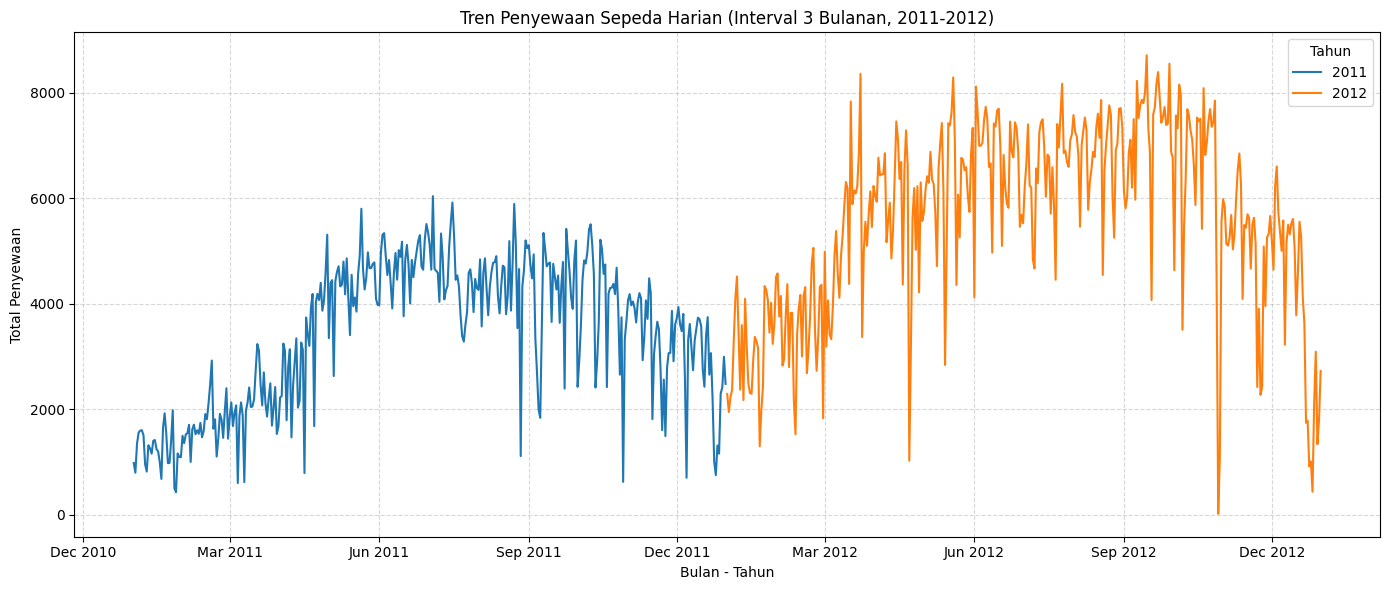

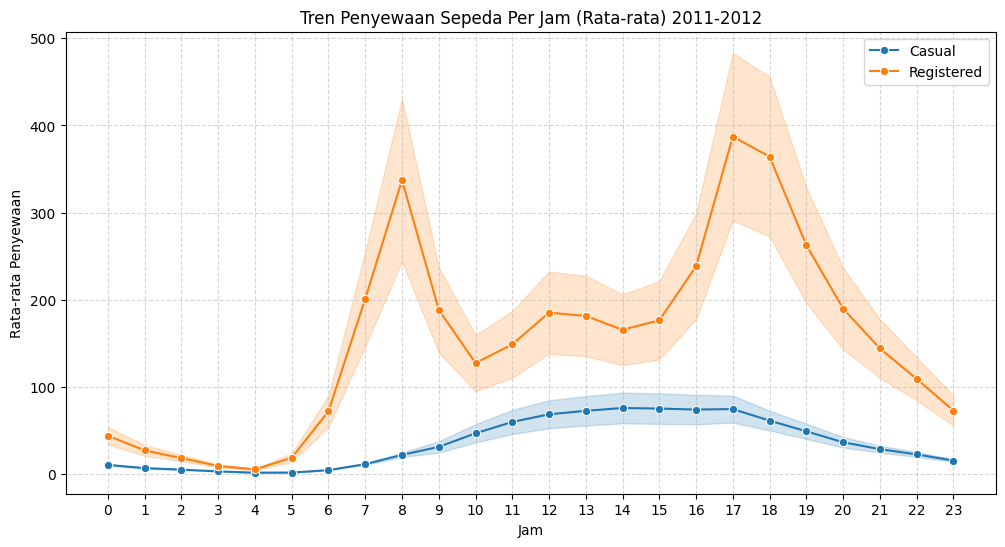

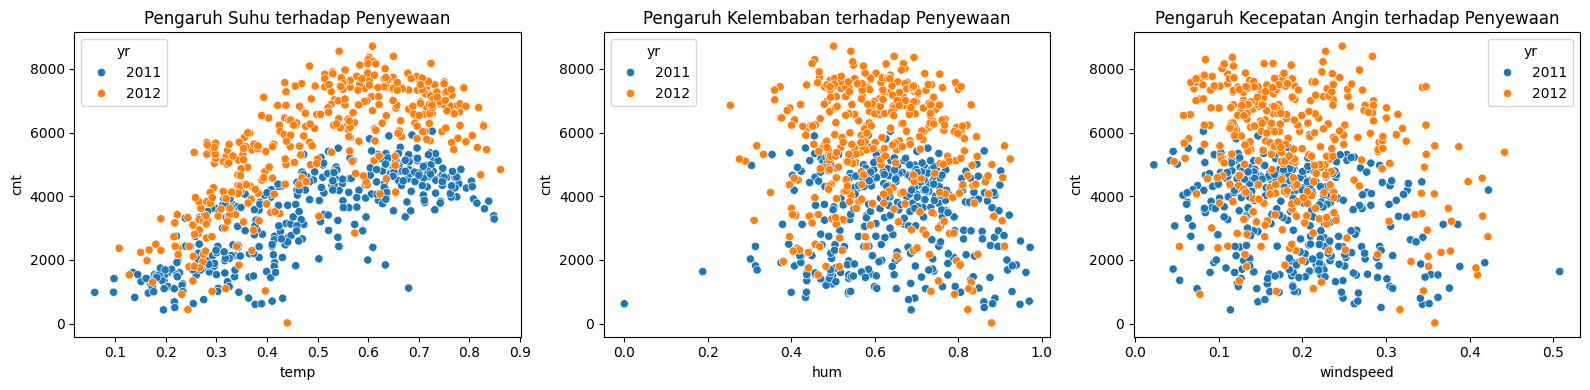

In [46]:
# Mapping kategori
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_labels = {1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Severe Weather'}
weekday_labels = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
year_labels = {0: '2011', 1: '2012'}

for df in [day_df, hour_df]:
    df['season'] = df['season'].replace(season_labels)
    df['weathersit'] = df['weathersit'].replace(weather_labels)
    df['weekday'] = df['weekday'].replace(weekday_labels)
    df['yr'] = df['yr'].replace(year_labels)

# ----- Agregasi data harian -----
daily_analysis = day_df.groupby(by=["yr", "dteday"]).agg({
    "casual": "sum",
    "registered": "sum",
    "cnt": "sum",
    "temp": "mean",
    "hum": "mean",
    "windspeed": "mean"
}).reset_index()

# ----- Agregasi data per jam -----
hour_analysis = hour_df.groupby(by=["yr", "hr"]).agg({
    "casual": "mean",
    "registered": "mean",
    "cnt": "mean",
    "temp": "mean",
    "hum": "mean",
    "windspeed": "mean"
}).reset_index()


# ----- Visualisasi Tren Harian (Dengan Interval 3 Bulan) -----
plt.figure(figsize=(14, 6))

# Pastikan dteday sudah bertipe datetime
daily_analysis['dteday'] = pd.to_datetime(daily_analysis['dteday'])

# Plot menggunakan dteday sebagai x
ax = sns.lineplot(data=daily_analysis, x="dteday", y="cnt", hue="yr")

# --- MENGATUR INTERVAL SUMBU X ---
# Menentukan jeda interval setiap 3 bulan
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Menentukan format tampilan label (Contoh: Jan 2011)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title("Tren Penyewaan Sepeda Harian (Interval 3 Bulanan, 2011-2012)")
plt.xlabel("Bulan - Tahun")
plt.ylabel("Total Penyewaan")

# Rotasi sedikit agar lebih elegan, namun tidak akan bertumpuk karena interval sudah diatur
plt.xticks(rotation=0)

plt.legend(title="Tahun")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ----- Visualisasi Tren Per Jam -----
plt.figure(figsize=(12,6))
sns.lineplot(data=hour_analysis, x="hr", y="casual", label="Casual", marker='o')
sns.lineplot(data=hour_analysis, x="hr", y="registered", label="Registered", marker='o')
plt.title("Tren Penyewaan Sepeda Per Jam (Rata-rata) 2011-2012")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0,24))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ----- Visualisasi Faktor Cuaca -----
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.scatterplot(data=daily_analysis, x="temp", y="cnt", hue="yr")
plt.title("Pengaruh Suhu terhadap Penyewaan")

plt.subplot(1,3,2)
sns.scatterplot(data=daily_analysis, x="hum", y="cnt", hue="yr")
plt.title("Pengaruh Kelembaban terhadap Penyewaan")

plt.subplot(1,3,3)
sns.scatterplot(data=daily_analysis, x="windspeed", y="cnt", hue="yr")
plt.title("Pengaruh Kecepatan Angin terhadap Penyewaan")

plt.tight_layout()
plt.show()

### Pertanyaan 2:

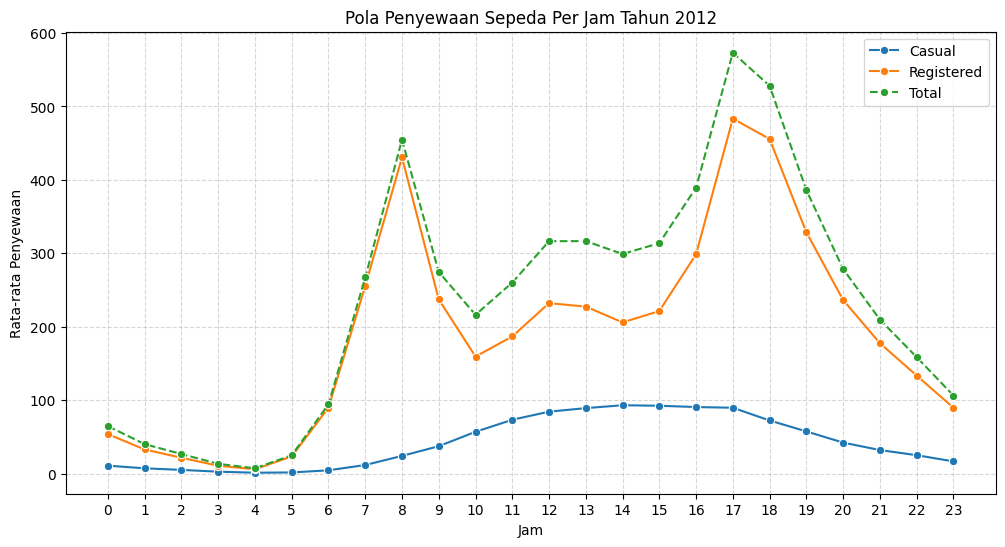

(hr             14.000000
 casual         93.128767
 registered    205.967123
 cnt           299.095890
 Name: 14, dtype: float64,
 hr             17.000000
 casual         89.717808
 registered    483.509589
 cnt           573.227397
 Name: 17, dtype: float64,
 hr             17.000000
 casual         89.717808
 registered    483.509589
 cnt           573.227397
 Name: 17, dtype: float64)

In [47]:
# Filter data tahun 2012
hour_2012 = hour_df[hour_df['yr'] == '2012']

# Agregasi per jam
hourly_2012 = hour_2012.groupby("hr").agg({
    "casual": "mean",
    "registered": "mean",
    "cnt": "mean"
}).reset_index()

# Visualisasi pola per jam 2012
plt.figure(figsize=(12,6))
sns.lineplot(data=hourly_2012, x="hr", y="casual", label="Casual", marker='o')
sns.lineplot(data=hourly_2012, x="hr", y="registered", label="Registered", marker='o')
sns.lineplot(data=hourly_2012, x="hr", y="cnt", label="Total", marker='o', linestyle='--')
plt.title("Pola Penyewaan Sepeda Per Jam Tahun 2012")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0,24))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Menampilkan jam puncak penggunaan
peak_casual = hourly_2012.loc[hourly_2012['casual'].idxmax()]
peak_registered = hourly_2012.loc[hourly_2012['registered'].idxmax()]
peak_total = hourly_2012.loc[hourly_2012['cnt'].idxmax()]

peak_casual, peak_registered, peak_total

**Insight:**

Pertanyaan 1:
- Tren penyewaan sepeda harian pada periode 2011–2012 menunjukkan peningkatan yang signifikan, di mana jumlah penyewaan pada tahun 2012 secara konsisten lebih tinggi dibandingkan tahun 2011.
- Pada kedua tahun, terlihat adanya pola musiman, di mana penyewaan cenderung meningkat pada pertengahan tahun dan menurun di awal serta akhir tahun.
- Fluktuasi harian cukup tinggi, namun secara umum tren tetap menunjukkan peningkatan dari waktu ke waktu, terutama pada tahun 2012.
- Pola penyewaan per jam menunjukkan pola bimodal dengan dua puncak utama, yaitu pada pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00.
- Pengguna registered mendominasi penyewaan dan mengalami lonjakan signifikan pada jam sibuk, terutama sore hari, yang menunjukkan penggunaan untuk aktivitas komuter.
- Pengguna casual memiliki pola yang lebih landai dan cenderung meningkat pada siang hingga sore hari, yang mengindikasikan penggunaan untuk rekreasi.
- Faktor suhu memiliki pengaruh paling kuat terhadap jumlah penyewaan, di mana semakin tinggi suhu (hingga batas tertentu), jumlah penyewaan cenderung meningkat secara signifikan.
- Kelembaban menunjukkan hubungan negatif terhadap penyewaan, di mana semakin tinggi tingkat kelembaban, jumlah penyewaan cenderung menurun.
- Kecepatan angin (windspeed) memiliki pengaruh yang relatif lemah terhadap jumlah penyewaan, karena sebaran data terlihat lebih acak dan tidak menunjukkan pola hubungan yang kuat.
- Secara keseluruhan, suhu merupakan faktor cuaca yang paling memengaruhi jumlah penyewaan sepeda dibandingkan dengan kelembaban dan kecepatan angin.

Pertanyaan 2:
- Pola penyewaan sepeda per jam pada tahun 2012 menunjukkan pola bimodal dengan dua puncak utama, yaitu pada pagi dan sore hari.
- Pada dini hari hingga subuh, jumlah penyewaan sangat rendah karena minimnya aktivitas pengguna.
- Penyewaan mulai meningkat pada pagi hari sekitar pukul 07.00–08.00 yang mencerminkan waktu berangkat kerja atau sekolah.
- Pada siang hari, jumlah penyewaan cenderung stabil tanpa lonjakan yang signifikan.
- Puncak tertinggi penyewaan terjadi pada sore hari sekitar pukul 17.00, yang merupakan waktu pulang kerja.
- Pengguna registered mendominasi jumlah penyewaan dan mencapai puncaknya pada pukul 17.00 dengan jumlah sekitar 483 penyewaan.
- Pengguna casual mencapai puncak penggunaan pada pukul 14.00 dengan jumlah sekitar 93 penyewaan.
- Pola ini menunjukkan bahwa pengguna registered cenderung menggunakan sepeda untuk aktivitas komuter, sedangkan pengguna casual lebih banyak menggunakan sepeda untuk keperluan santai pada siang hari.


## Analisis Lanjutan (Opsional)

Hasil Analisis Manual Grouping:
                 cnt                         temp
               count         mean   max      mean
usage_category                                   
Low Demand        98  1394.775510  1996  0.270218
Medium Demand    347  3773.103746  4996  0.485328
High Demand      286  6457.076923  8714  0.584742


/tmp/ipykernel_7750/4057744044.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=day_df, x='usage_category', order=['Low Demand', 'Medium Demand', 'High Demand'], palette='viridis')


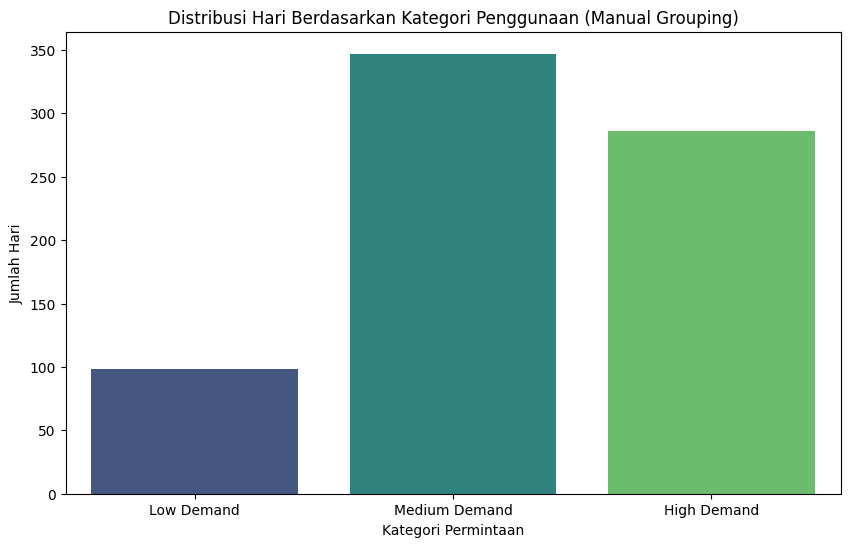

In [48]:
# 1. Menentukan kriteria pengelompokan berdasarkan pemahaman data
# Misalnya kita bagi berdasarkan jumlah total penyewaan (cnt)
# Rendah: < 2000, Sedang: 2000 - 5000, Tinggi: > 5000

def manual_category(cnt):
    if cnt < 2000:
        return 'Low Demand'
    elif 2000 <= cnt <= 5000:
        return 'Medium Demand'
    else:
        return 'High Demand'

# 2. Menerapkan pengelompokan ke kolom baru
day_df['usage_category'] = day_df['cnt'].apply(manual_category)

# 3. Melihat ringkasan hasil pengelompokan
manual_group_summary = day_df.groupby('usage_category').agg({
    'cnt': ['count', 'mean', 'max'],
    'temp': 'mean'
}).reindex(['Low Demand', 'Medium Demand', 'High Demand'])

print("Hasil Analisis Manual Grouping:")
print(manual_group_summary)

# 4. Visualisasi Sederhana
plt.figure(figsize=(10, 6))
sns.countplot(data=day_df, x='usage_category', order=['Low Demand', 'Medium Demand', 'High Demand'], palette='viridis')

plt.title('Distribusi Hari Berdasarkan Kategori Penggunaan (Manual Grouping)')
plt.xlabel('Kategori Permintaan')
plt.ylabel('Jumlah Hari')
plt.show()

**Insight:**

- Tujuan Analisis Lanjutan: Tujuan dari analisis ini adalah untuk mengelompokkan hari-hari operasional berdasarkan performa jumlah penyewaan sepeda guna memahami distribusi tingkat permintaan (Rendah, Sedang, Tinggi) dan melihat bagaimana faktor eksternal seperti suhu memengaruhi setiap kategori tersebut.
- Teknik yang Digunakan: Teknik yang digunakan adalah Manual Grouping, yaitu metode pengelompokan data ke dalam beberapa kategori berdasarkan batasan (threshold) nilai tertentu yang ditentukan secara manual.
- Interpretasi Hasil Analisis Lanjutan:
  * Dominasi Permintaan Menengah dan Tinggi: Sebagian besar hari dalam periode 2011-2012 berada pada kategori Medium Demand (347 hari) dan High Demand (286 hari). Hal ini menunjukkan bahwa bisnis penyewaan sepeda memiliki performa yang baik karena mayoritas hari mencatatkan penyewaan di atas 2.000 unit.
  * Hubungan Kuat Antara Suhu dan Permintaan: Terdapat tren kenaikan suhu yang sejajar dengan kenaikan permintaan. Pada kategori Low Demand, rata-rata suhu hanya berada di angka 0.27, sedangkan pada kategori High Demand, rata-rata suhu meningkat signifikan menjadi 0.58. Ini membuktikan bahwa pengguna lebih cenderung menyewa sepeda pada cuaca yang lebih hangat.
  * Skalabilitas Operasional: Dengan rata-rata penyewaan mencapai 6.457 unit pada hari-hari High Demand, perusahaan perlu memastikan ketersediaan armada dan kesiapan petugas pemeliharaan pada musim-musim dengan suhu yang mendukung, karena pada hari-hari tersebut jumlah penyewaan bisa melonjak hingga maksimal 8.714 unit. Sebaliknya, periode Low Demand (98 hari) dapat dimanfaatkan untuk jadwal perawatan rutin sepeda.

## Conclusion

- Conclution pertanyaan 1: Tren penyewaan sepeda pada periode 2011–2012 menunjukkan peningkatan yang signifikan, di mana jumlah penyewaan pada tahun 2012 lebih tinggi dibandingkan tahun 2011. Meskipun terdapat fluktuasi harian, pola umum tetap menunjukkan tren meningkat dengan adanya indikasi pola musiman. Dari sisi faktor cuaca, suhu memiliki pengaruh paling kuat terhadap jumlah penyewaan, di mana peningkatan suhu diikuti dengan peningkatan jumlah penyewaan. Sebaliknya, kelembaban memiliki hubungan negatif karena tingkat kelembaban yang tinggi cenderung menurunkan jumlah penyewaan, sementara kecepatan angin memiliki pengaruh yang relatif kecil. Dengan demikian, dapat disimpulkan bahwa kondisi cuaca, terutama suhu, menjadi faktor utama yang memengaruhi tingkat penyewaan sepeda.
- Conclution pertanyaan 2: Pola penyewaan sepeda per jam pada tahun 2012 menunjukkan pola bimodal dengan dua puncak utama pada pagi dan sore hari. Penyewaan mulai meningkat pada pagi hari sekitar pukul 07.00–08.00 yang mencerminkan aktivitas berangkat kerja atau sekolah, dan mencapai puncak tertinggi pada sore hari sekitar pukul 17.00 yang merupakan waktu pulang kerja. Pengguna registered mendominasi jumlah penyewaan, terutama pada jam sibuk, sedangkan pengguna casual cenderung mencapai puncak pada siang hari sekitar pukul 14.00 yang menunjukkan penggunaan untuk aktivitas santai atau rekreasi. Secara keseluruhan, pola penyewaan sepeda sangat dipengaruhi oleh aktivitas harian masyarakat, khususnya mobilitas kerja.

In [49]:
# Simpan dataframe hasil analisis ke CSV dengan nama main_data.csv
hour_df.to_csv("main_data.csv", index=False)